In [1]:
import pandas as pd

df = pd.read_csv('/content/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [2]:
print(df.shape)

(1470, 35)


In [3]:
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
print(df.duplicated().sum())

0


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df['Attrition'] = df['Attrition'].map({
    'Yes': 1,
    'No': 0
})

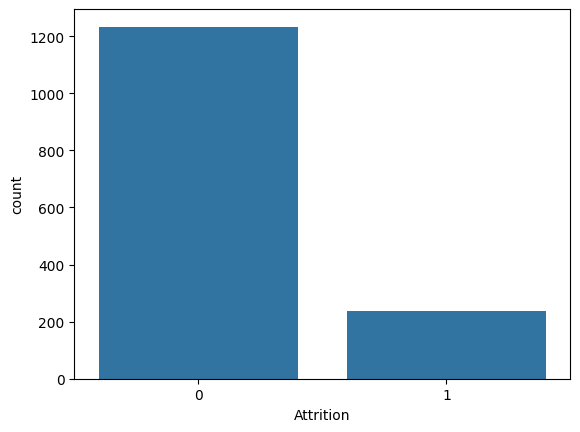

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Attrition', data=df)

plt.show()

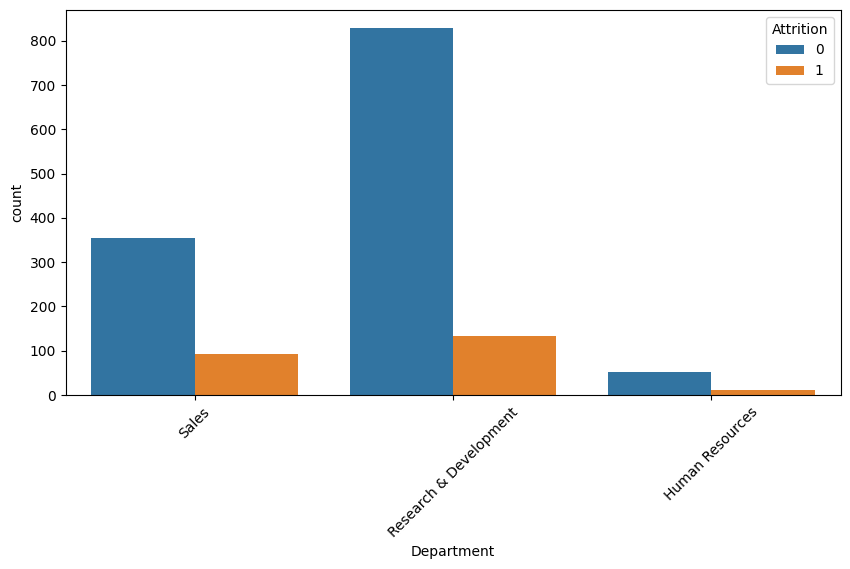

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Department',
    hue='Attrition',
    data=df
)

plt.xticks(rotation=45)

plt.show()

In [11]:
df.to_csv(
    'cleaned_employee_attrition.csv',
    index=False
)

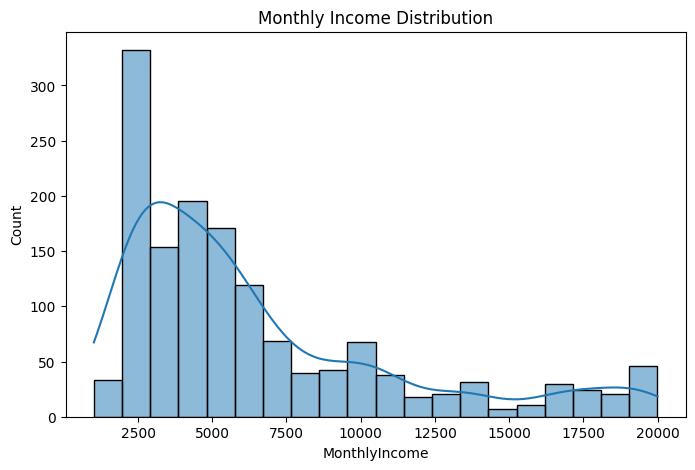

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['MonthlyIncome'],
    kde=True
)

plt.title("Monthly Income Distribution")

plt.show()

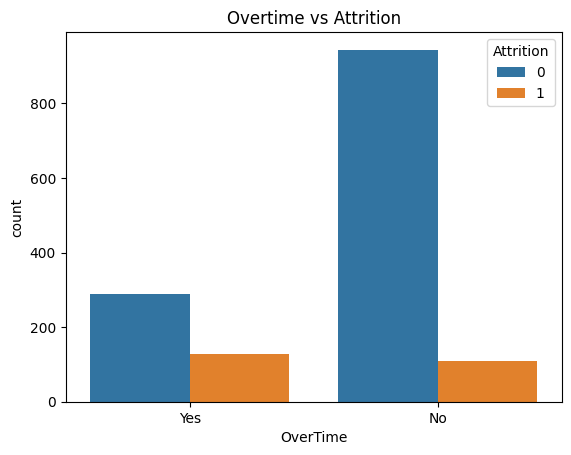

In [13]:
sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df
)

plt.title("Overtime vs Attrition")

plt.show()

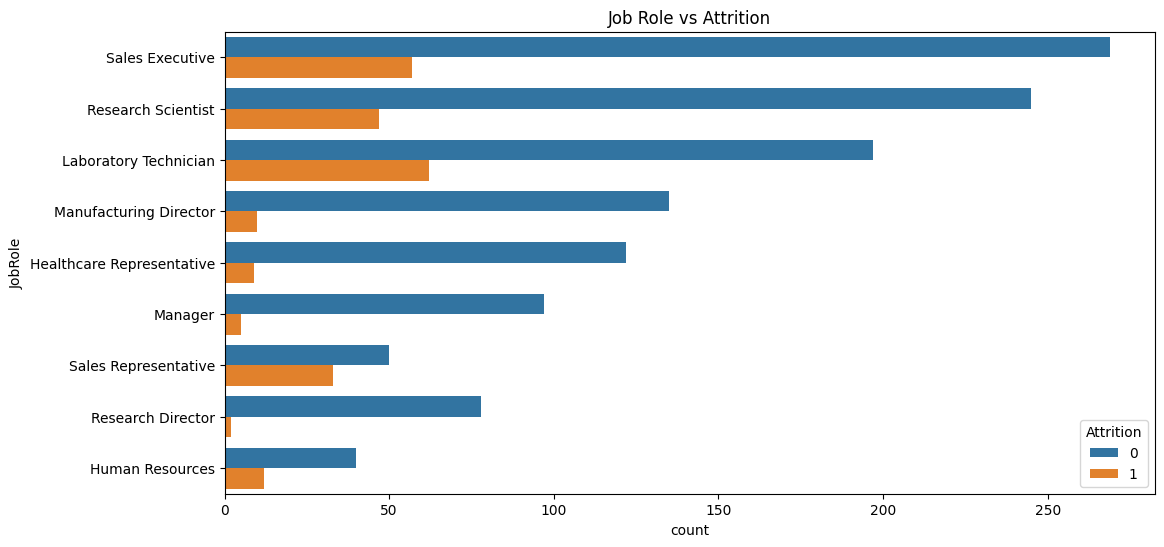

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='JobRole',
    hue='Attrition',
    data=df
)

plt.title("Job Role vs Attrition")

plt.show()

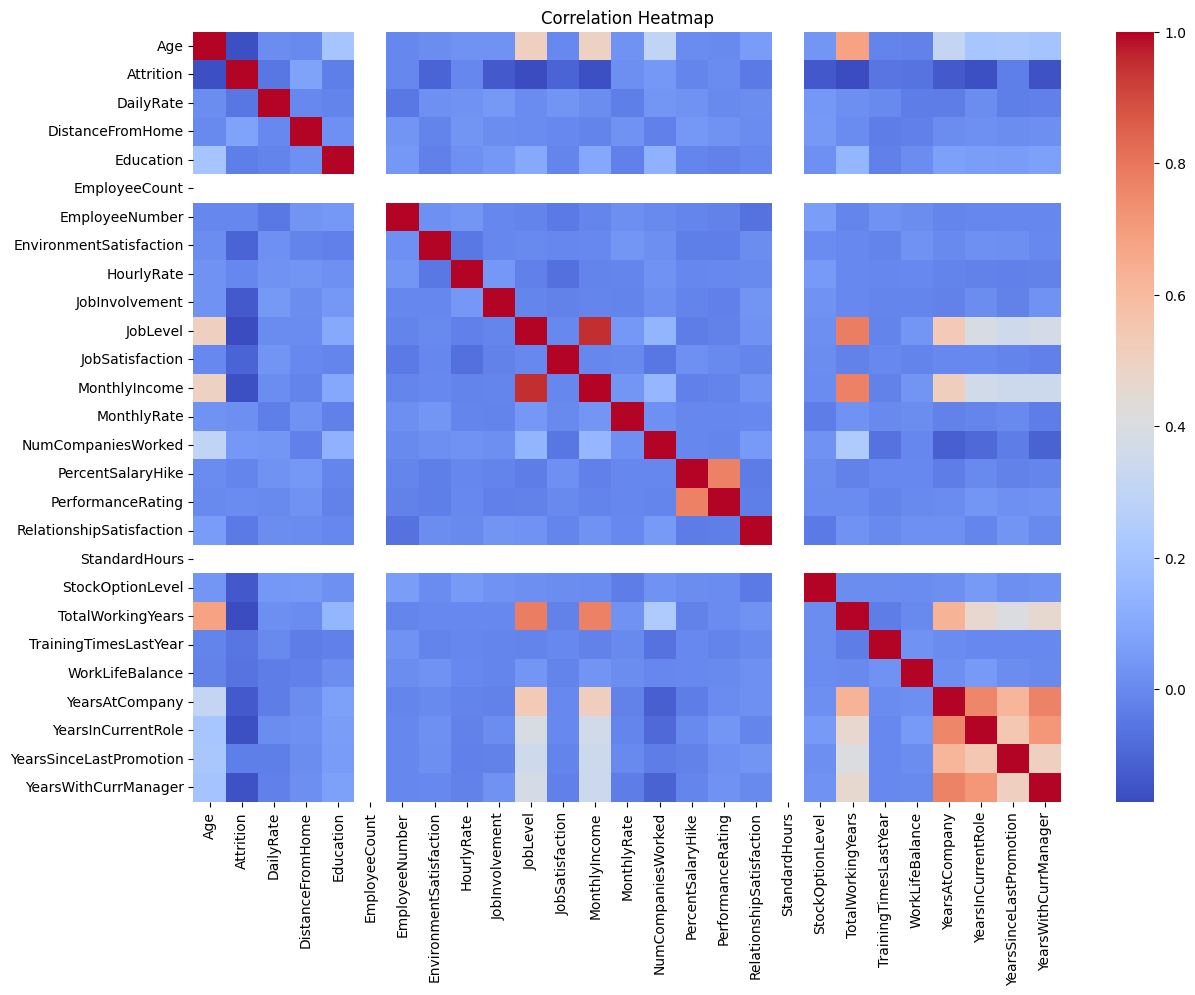

In [15]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [16]:
attrition_rate = (
    df['Attrition'].value_counts(normalize=True)
    * 100
)

print(attrition_rate)

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64


1. Sales department has highest attrition.
2. Employees with overtime leave more.
3. Lower salary employees show higher attrition.
4. Younger employees leave more frequently.

In [17]:
df.to_csv(
    'final_cleaned_employee_data.csv',
    index=False
)

In [18]:
df.select_dtypes(include='object').columns

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')

In [19]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)

(1470, 48)


In [20]:
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,1,2,94,3,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,2,3,61,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,4,92,2,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,5,4,56,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,7,1,40,3,...,True,False,False,False,False,False,False,True,False,False


In [21]:
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [22]:
df['Attrition'].value_counts(normalize=True) * 100

,proportion
Attrition,
0,83.877551
1,16.122449


In [23]:
df.groupby('Attrition')[['Age','MonthlyIncome','YearsAtCompany']].mean()

,Age,MonthlyIncome,YearsAtCompany
Attrition,,,
0,37.561233,6832.739659,7.369019
1,33.607595,4787.092827,5.130802


In [24]:
df['IncomePerYear'] = (
    df['MonthlyIncome'] * 12
) / (df['YearsAtCompany'] + 1)

In [25]:
df[['IncomePerYear']].head()

,IncomePerYear
0,10273.714286
1,5596.363636
2,25080.000000
3,3878.666667
4,13872.000000


In [26]:
df.to_csv(
    'employee_attrition_feature_engineered.csv',
    index=False
)

In [27]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,IncomePerYear
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,10273.714286
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,5596.363636
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,25080.000000
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,3878.666667
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,13872.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,80,1,17,3,3,5,2,0,3,5142.000000
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,80,1,9,5,3,7,7,1,7,14986.500000
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,80,1,6,0,3,6,2,0,3,10529.142857
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,80,0,17,3,2,9,6,0,8,6468.000000


In [28]:
df.to_csv("cleaned_employee_attrition.csv", index=False)